In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This file contains the software model for implementation of a 2 layered NN with quantization.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from sklearn.utils import shuffle


import importlib.util, os

dataset_path = "/content/drive/MyDrive/EE6347/4alphabet_dataset.py" #include the files given in zip file and gice appropriate path for all the files
spec = importlib.util.spec_from_file_location("alphabet", dataset_path)
alphabet = importlib.util.module_from_spec(spec)
spec.loader.exec_module(alphabet)

print("Dataset loaded.")


Dataset loaded.


In [ ]:
def augment_training(X, y, n_copies=40, noise_std=0.10, seed=1234):
    """
    Augments training samples by adding Gaussian noise (safe augmentation).
    - X must be in range [0, 1]
    - Produces n_copies noisy variants per training sample
    - Does NOT perform bit-flips (to avoid validation leakage)
    """
    rng = np.random.RandomState(seed)
    X_aug = []
    y_aug = []

    for xi, yi in zip(X, y):
        # Keep original sample
        X_aug.append(xi)
        y_aug.append(yi)

        # Create n_copies noisy samples
        for _ in range(n_copies):
            noise = rng.normal(loc=0.0, scale=noise_std, size=xi.shape)
            x_noisy = xi + noise
            x_noisy = np.clip(x_noisy, 0.0, 1.0)  # keep images valid
            X_aug.append(x_noisy)
            y_aug.append(yi)

    return np.vstack(X_aug).astype(np.float32), np.array(y_aug)


In [ ]:
# Load true dataset (10 samples per class)
A_true, T_true, V_true, X_true = alphabet.training_set()

# Load deterministic bit-flip test set
TestValid = alphabet.test_set(A_true, T_true, V_true, X_true)

print("Training Shapes:")
print(A_true.shape, T_true.shape, V_true.shape, X_true.shape)
print("Test shape:", TestValid.shape)


Training Shapes:
(10, 4, 4) (10, 4, 4) (10, 4, 4) (10, 4, 4)
Test shape: (4, 160, 4, 4)


In [ ]:
def prepare_train_data(A, T, V, X):
    X = np.vstack([
        A.reshape(10, -1),
        T.reshape(10, -1),
        V.reshape(10, -1),
        X.reshape(10, -1)
    ])
    y = np.array([0]*10 + [1]*10 + [2]*10 + [3]*10)
    return shuffle(X.astype("float32"), y)

def prepare_test_data(TestValid):
    X_list, y_list = [], []
    for cls in range(4):
        Xc = TestValid[cls].reshape(160, -1)
        X_list.append(Xc)
        y_list += [cls]*160
    return np.vstack(X_list).astype("float32"), np.array(y_list)

X_train, y_train = prepare_train_data(A_true, T_true, V_true, X_true)
X_test, y_test = prepare_test_data(TestValid)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# One-hot encode labels
y_train_oh = to_categorical(y_train, 4)
y_test_oh = to_categorical(y_test, 4)

print(X_train)
print("\n")
print(len(X_test))

X_train: (40, 16)
X_test: (640, 16)
[[1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.]
 [1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.]
 [0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1.]
 [0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1.]
 [0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0.]
 [1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1.]
 [1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0.

In [ ]:
# Create a copy for augmentation
X_train_norm = X_train.copy()

# Augment training data (140 copies, 0.2 noise)
X_train_aug, y_train_aug = augment_training(
    X_train_norm, y_train,
    n_copies=140,
    noise_std=0.2
)

# Shuffle the data (Essential for training)
X_train_aug, y_train_aug = shuffle(X_train_aug, y_train_aug, random_state=42)

print("Original training size :", X_train.shape)
print("Augmented training size:", X_train_aug.shape)

# One-hot encode labels
y_train_aug_oh = to_categorical(y_train_aug, 4)
y_test_oh = to_categorical(y_test, 4)


Original training size : (40, 16)
Augmented training size: (5640, 16)


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.constraints import MinMaxNorm
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Base model (training) builder
# -----------------------------
def build_train_model():
    model = Sequential([
        Dense(8,
              activation='tanh',
              input_shape=(16,),
              kernel_constraint=MinMaxNorm(min_value=0.0, max_value=1.0)), # Constrain weights for RRAM compatibility
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# Quantization function (kernel + bias)
# -----------------------------
def quantize_layer_binary(weights):
    kernel, bias = weights  # kernel: (in_dim, out_dim), bias: (out_dim,)

    # Compute a single mean over the whole layer (kernel + bias)
    all_params = np.concatenate([kernel.ravel(), bias.ravel()])
    thr = np.mean(all_params)

    # Quantize BOTH kernel and bias using this threshold
    q_kernel = (kernel >= thr).astype(np.float32)  # 0.0 or 1.0
    q_bias   = (bias   >= thr).astype(np.float32)  # 0.0 or 1.0

    return [q_kernel, q_bias]

# -----------------------------
# Quantized model builder
# -----------------------------
def build_quantized_model(original):
    qmodel = Sequential([
        Dense(8, activation='tanh', input_shape=(16,)),
        Dense(4, activation='softmax')
    ])

    # Copy and quantize weights layer by layer
    for orig_layer, q_layer in zip(original.layers, qmodel.layers):
        w = orig_layer.get_weights()
        if len(w) > 0:
            q_layer.set_weights(quantize_layer_binary(w))

    qmodel.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return qmodel

In [ ]:
print(X_train_aug)

[[0.25546414 0.07374026 0.         ... 0.11414453 0.9262798  0.04376027]
 [1.         1.         0.7247122  ... 0.18244977 0.24910428 0.31535694]
 [0.06645802 0.         0.40205386 ... 1.         0.17218943 0.00117058]
 ...
 [0.14728275 0.9292132  1.         ... 0.23073171 0.         1.        ]
 [0.01095527 1.         0.84679717 ... 0.11321514 0.         1.        ]
 [0.         0.7296057  0.         ... 0.50013137 0.85595006 0.40769994]]


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.constraints import MinMaxNorm
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Base model (training) builder
# -----------------------------
def build_train_model():
    model = Sequential([
        Dense(8,
              activation='tanh',
              input_shape=(16,),
              kernel_constraint=MinMaxNorm(min_value=0.0, max_value=1.0)), # Constrain weights for RRAM compatibility
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# Quantization function (kernel + bias)
# -----------------------------
def quantize_layer_binary(weights):
    kernel, bias = weights  # kernel: (in_dim, out_dim), bias: (out_dim,)

    # Compute a single mean over the whole layer (kernel + bias)
    all_params = np.concatenate([kernel.ravel(), bias.ravel()])
    thr = np.mean(all_params)

    # Quantize BOTH kernel and bias using this threshold
    q_kernel = (kernel >= thr).astype(np.float32)  # 0.0 or 1.0
    q_bias   = (bias   >= thr).astype(np.float32)  # 0.0 or 1.0

    return [q_kernel, q_bias]

# -----------------------------
# Quantized model builder
# -----------------------------
def build_quantized_model(original):
    qmodel = Sequential([
        Dense(8, activation='tanh', input_shape=(16,)),
        Dense(4, activation='softmax')
    ])

    # Copy and quantize weights layer by layer
    for orig_layer, q_layer in zip(original.layers, qmodel.layers):
        w = orig_layer.get_weights()
        if len(w) > 0:
            q_layer.set_weights(quantize_layer_binary(w))

    qmodel.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return qmodel


# -----------------------------
# Train and Quantize Function
# -----------------------------
def train_and_quantize_once(run_idx, epochs=40, batch_size=16):
    # Set seed for reproducibility/exploration
    np.random.seed(run_idx)
    tf.random.set_seed(run_idx)

    model = build_train_model()

    # Scale X values from [0, 1] to [-1, 1]
    X_train_aug_scaled = X_train_aug * 2 - 1
    X_test_scaled = X_test * 2 - 1

    # Train on the AUGMENTED dataset with scaled inputs
    history = model.fit(
        X_train_aug_scaled, y_train_aug_oh,
        validation_data=(X_test_scaled, y_test_oh),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0  # set to 1 to see progress bars
    )

    # Evaluate floating-point model with scaled inputs
    loss_before, acc_before = model.evaluate(X_test_scaled, y_test_oh, verbose=0)

    # Create and evaluate quantized model with scaled inputs
    qmodel = build_quantized_model(model)
    loss_after, acc_after = qmodel.evaluate(X_test_scaled, y_test_oh, verbose=0)

    return {
        "run_idx": run_idx,
        "model": model,
        "qmodel": qmodel,
        "acc_before": acc_before,
        "acc_after": acc_after,
    }

# -----------------------------
# Run Loop (Track Best Model)
# -----------------------------
num_runs = 25   # Set to 100 for more exhaustive search
best_result = None

print(f"Starting {num_runs} training runs...")

for i in range(num_runs):
    result = train_and_quantize_once(i)

    print(f"Run {i}: Pre-Q Acc = {result['acc_before']:.4f}, "
          f"Post-Q Acc = {result['acc_after']:.4f}")

    # Logic to save the best performing QUANTIZED model
    if best_result is None or result["acc_after"] > best_result["acc_after"]:
        best_result = result

print("\n=== BEST RUN SUMMARY ===")
print(f"Best run index: {best_result['run_idx']}")
print(f"Best pre-quant accuracy:  {best_result['acc_before']:.4f}")
print(f"Best post-quant accuracy: {best_result['acc_after']:.4f}")

# Save the best model for later use
best_model_float = best_result["model"]
best_qmodel = best_result["qmodel"]

Starting 25 training runs...
Run 0: Pre-Q Acc = 0.9719, Post-Q Acc = 0.4141
Run 1: Pre-Q Acc = 0.9844, Post-Q Acc = 0.6281
Run 2: Pre-Q Acc = 0.9187, Post-Q Acc = 0.2859
Run 3: Pre-Q Acc = 0.9875, Post-Q Acc = 0.3016
Run 4: Pre-Q Acc = 0.8687, Post-Q Acc = 0.4766
Run 5: Pre-Q Acc = 0.9563, Post-Q Acc = 0.3063
Run 6: Pre-Q Acc = 0.8734, Post-Q Acc = 0.3766
Run 7: Pre-Q Acc = 0.9266, Post-Q Acc = 0.2875
Run 8: Pre-Q Acc = 0.9828, Post-Q Acc = 0.6109
Run 9: Pre-Q Acc = 0.9766, Post-Q Acc = 0.3734
Run 10: Pre-Q Acc = 0.9094, Post-Q Acc = 0.5297
Run 11: Pre-Q Acc = 0.9281, Post-Q Acc = 0.5047
Run 12: Pre-Q Acc = 0.9547, Post-Q Acc = 0.2766
Run 13: Pre-Q Acc = 0.9109, Post-Q Acc = 0.3453
Run 14: Pre-Q Acc = 0.9531, Post-Q Acc = 0.4375
Run 15: Pre-Q Acc = 0.9828, Post-Q Acc = 0.6219
Run 16: Pre-Q Acc = 0.9563, Post-Q Acc = 0.4328
Run 17: Pre-Q Acc = 0.9812, Post-Q Acc = 0.2656
Run 18: Pre-Q Acc = 0.9469, Post-Q Acc = 0.4094
Run 19: Pre-Q Acc = 0.9047, Post-Q Acc = 0.5281
Run 20: Pre-Q Acc = 0

### **ABOVE IS THE ACCURACY OF OUR SOFTWARE IMPLEMENTATION** ^^^


In [ ]:
# Inspect / export weights from the best quantized model
for i, layer in enumerate(best_qmodel.layers):
    w = layer.get_weights()
    if len(w) == 0:
        continue

    kernel, bias = w
    print(f"\n=== Layer {i} ({layer.name}) ===")
    print("Kernel (0/1) shape:", kernel.shape)
    print(kernel.astype(int))   # for readability

    print("Bias (0/1) shape:", bias.shape)
    print(bias.astype(int))



=== Layer 0 (dense_50) ===
Kernel (0/1) shape: (16, 8)
[[1 0 1 1 0 0 0 0]
 [0 1 0 0 1 1 1 1]
 [1 0 1 1 1 0 0 1]
 [1 1 0 0 1 1 1 1]
 [1 0 1 0 1 1 0 1]
 [0 0 0 1 1 1 1 0]
 [1 1 1 0 0 0 1 1]
 [0 0 0 0 1 1 1 0]
 [0 0 1 1 1 1 0 1]
 [1 1 0 0 1 1 0 1]
 [0 0 1 1 1 1 1 1]
 [0 1 1 1 1 1 0 0]
 [1 1 0 0 1 1 0 1]
 [0 0 1 1 1 0 1 0]
 [1 0 0 0 0 1 0 1]
 [0 1 0 1 1 1 1 0]]
Bias (0/1) shape: (8,)
[0 0 0 0 0 0 1 0]

=== Layer 1 (dense_51) ===
Kernel (0/1) shape: (8, 4)
[[0 0 0 1]
 [0 0 0 1]
 [0 1 1 0]
 [1 0 0 1]
 [1 0 0 0]
 [1 0 1 0]
 [0 1 0 0]
 [1 1 0 0]]
Bias (0/1) shape: (4,)
[1 0 1 1]


In [ ]:
q_kernel_layer0, q_bias_layer0 = best_qmodel.layers[0].get_weights()

print(f"Kernel weights for Layer 0 (shape {q_kernel_layer0.shape}):")
print(q_kernel_layer0.astype(int))

print(f"Bias weights for Layer 0 (shape {q_bias_layer0.shape}):")
print(q_bias_layer0.astype(int))

Kernel weights for Layer 0 (shape (16, 8)):
[[1 0 1 1 0 0 0 0]
 [0 1 0 0 1 1 1 1]
 [1 0 1 1 1 0 0 1]
 [1 1 0 0 1 1 1 1]
 [1 0 1 0 1 1 0 1]
 [0 0 0 1 1 1 1 0]
 [1 1 1 0 0 0 1 1]
 [0 0 0 0 1 1 1 0]
 [0 0 1 1 1 1 0 1]
 [1 1 0 0 1 1 0 1]
 [0 0 1 1 1 1 1 1]
 [0 1 1 1 1 1 0 0]
 [1 1 0 0 1 1 0 1]
 [0 0 1 1 1 0 1 0]
 [1 0 0 0 0 1 0 1]
 [0 1 0 1 1 1 1 0]]
Bias weights for Layer 0 (shape (8,)):
[0 0 0 0 0 0 1 0]



 pwl(time, 0us, 0V, 5us, 1.20V, 200us, 1.20V, 205us, 0V, 400us, 0V, 405us, 0.10V, 600us, 0.10V, 605us, 0V, 800us, 0V, 805us, -1.20V, 1000us, -1.20V, 1005us, 0V, 1200us, 0V, 1205us, 0.10V, 1400us, 0.10V, 1405us, 0V, 1600us, 0V)

'   index     time      A      X      V      T
0      0  0e-6sec  4e-2V  1e-3V  2e-3V  1e-3V
1      1  1e-6sec  3e-2V  2e-3V  1e-3V  2e-3V
2      2  2e-6sec  5e-2V  1e-3V  2e-3V  1e-3V
3      3  3e-6sec  1e-3V  4e-2V  1e-3V  2e-3V
4      4  4e-6sec  2e-3V  5e-2V  2e-3V  1e-3V

   index      time      A      X      V      T
0      0  0.000000  0.040  0.001  0.002  0.001
1      1  0.000001  0.030  0.002  0.001  0.002
2      2  0.000002  0.050  0.001  0.002  0.001
3      3  0.000003  0.001  0.040  0.001  0.002
4      4  0.000004  0.002  0.050  0.002  0.001



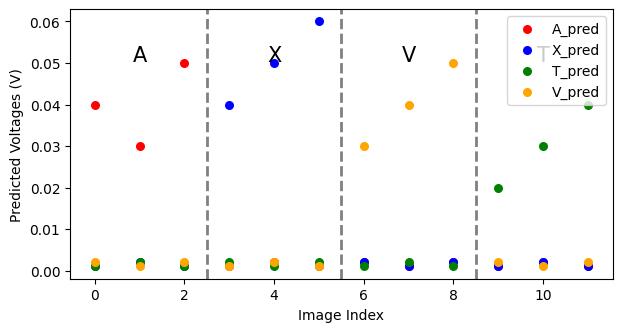

In [1]:
# helper code for reference used in the Scattering plot implementation found in Accuracy_EE6347.py file

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pwl(signal, pulsewidth, slewtime):
    '''Given a space separated voltages, this generates
        a PWL pulse train for SPICE simulations.
        pulsewidth and slewtime are in microseconds'''
    t = 0
    pw = pulsewidth
    st = slewtime
    res = "pwl(time, 0us, 0V"
    for i in signal:
        res += f", {t+st}us, {i:.2f}V, {t+pw}us, {i:.2f}V, {t+st+pw}us, 0V, {t+2*pw}us, 0V"
        t+= 2*pw
    res += ")"
    return res

def weights_to_signal(target):
    ''' Skeleton for you to write (Won't compile)
        Feel free to write your own from scratch too'''
    WL = [[] for _ in range(len(target))]
    BL = [[] for _ in range(len(target))]
    for ind_i, i in enumerate(target):
        for ind_j, j in enumerate(i):
            if j==1: continue # Code for what to do in WL[ind_j]
            else: continue # Code for what to do in WL[ind_j]
        for ind_k in range(len(target)):
            if ind_k==ind_i: continue # Code for what to do in BL[ind_k]
            else: continue # Code for what to do in BL[ind_k]
    return WL, BL

def image_to_signal(images, Vpos, Vneg, V_mode):
    ''' Skeleton for you to write (Won't compile)
        Feel free to write your own from scratch too'''
    WL = [[] for _ in range(len(images[0].flatten()))]
    Mode = []
    Mode_B = []
    for i in images:
        i = i.flatten()
        for ind, j in enumerate(i):
            WL[ind].append(Vpos if j==1 else Vneg)
        # Don't forget to also add 0s to all other signals
        # Otherwise the time scales between two different
        # voltage source won't match
        Mode = Mode + [-V_mode,]
        Mode_B = Mode_B + [V_mode,]

def remove_units_per_cell(value):
    return float(value.replace('E', 'e').split('V')[0].replace('sec', ''))

def remove_units_full_table(s):
    ''' Removes units in a dataframe containing values such as "1e-9V"'''
    s['time'] = s['time'].apply(remove_units_per_cell)
    for col in ['A', 'X', 'V', 'T']:
        s[col] = s[col].apply(remove_units_per_cell)
    return s

def scatter_plot(sampled, samples_per_class=40):
    ''' Scatter plot for predicted voltages'''
    plt.figure(figsize=(7, 3.5))

    plt.scatter(sampled.index, sampled['A'], color='red', label='A_pred', s=30, marker='o')  # Red dots for A
    plt.scatter(sampled.index, sampled['X'], color='blue', label='X_pred', s=30, marker='o')  # Blue dots for X
    plt.scatter(sampled.index, sampled['T'], color='green', label='T_pred', s=30, marker='o')  # Green dots for T
    plt.scatter(sampled.index, sampled['V'], color='orange', label='V_pred', s=30, marker='o')  # Orange dots for V

    plt.xlabel('Image Index')
    plt.ylabel('Predicted Voltages (V)')
    plt.legend()

    plt.axvline(x=samples_per_class-0.5, color='gray', linestyle='--', linewidth=2)
    plt.axvline(x=2*samples_per_class-0.5, color='gray', linestyle='--', linewidth=2)
    plt.axvline(x=3*samples_per_class-0.5, color='gray', linestyle='--', linewidth=2)

    plt.text(samples_per_class/2-0.5, plt.ylim()[1]*(0.8), 'A', fontsize=15, color='black', ha='center')
    plt.text(3*samples_per_class/2-0.5, plt.ylim()[1]*0.8, 'X', fontsize=15, color='black', ha='center')
    plt.text(5*samples_per_class/2-0.5, plt.ylim()[1]*0.8, 'V', fontsize=15, color='black', ha='center')
    plt.text(7*samples_per_class/2-0.5, plt.ylim()[1]*0.8, 'T', fontsize=15, color='black', ha='center')

    plt.show()

if __name__ == "__main__":
    # Example usage - PRER
    signal = [1.2 , 0.1, -1.2, 0.1]
    pwl_signal = pwl(signal, 200, 5)
    print('\n', pwl_signal, end="\n\n'")

    # Example usage - Units Removal
    df = pd.DataFrame({
        'index': list(range(12)),
        'time': [f'{i}e-6sec' for i in range(12)],
        'A': ['4e-2V', '3e-2V', '5e-2V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V'],
        'X': ['1e-3V', '2e-3V', '1e-3V', '4e-2V', '5e-2V', '6e-2V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V'],
        'V': ['2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '3e-2V', '4e-2V', '5e-2V', '2e-3V', '1e-3V', '2e-3V'],
        'T': ['1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-3V', '1e-3V', '2e-2V', '3e-2V', '4e-2V']
    })
    print(df.head(), end='\n\n')

    df_clean = remove_units_full_table(df)
    print(df_clean.head(), end='\n\n')

    # Example Usage - Scatter Plot
    scatter_plot(df_clean, 3)

